# **Welcome to Machine Learning/AI Workshop GDGOC**

**By Rahardi Salim**

Any questions? Feel free to reach out:

Instagram: @rahardi_salim | [LinkedIn](https://www.linkedin.com/in/rahardi-salim/)  | Email: rahardisalim23@gmail.com

## **1. Setup & Introduction**

Halo semuanya! Selamat datang di workshop ML. Notebook ini dirancang khusus agar **beginner-friendly**. Fokus kita adalah **praktik langsung** dan memahami workflow Machine Learning, jadi kita tidak akan terlalu dalam membahas matematika di balik algoritma atau detail teknis library-nya. Saya asumsikan kalian sudah mengerti dasar python dan statistika dasar :)

*Note: Kita akan menggunakan **Google Colab**, tapi bagi kalian yang ingin menggunakan Kaggle Notebook, langkah-langkahnya hampir sama.*

### **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agar output visualisasi muncul langsung di notebook
%matplotlib inline

## **2. Loading the Dataset**

Kita akan menggunakan dataset **Telco Customer Churn**. Dataset ini saya simpan di Google Drive agar mudah diakses lewat link.

*Tips: Jika ingin menggunakan data sendiri, kalian bisa klik icon folder di sidebar kiri Colab lalu pilih 'Upload'.*

Link Dataset Asli: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [ ]:
url = "https://drive.google.com/uc?export=download&id=1I3r6L6UQgMYaAOFWxxqxr2y-qdbDeeB-"
df = pd.read_csv(url)

# Menampilkan 5 data teratas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **3. Business Understanding**

Di dunia bisnis, mempertahankan pelanggan lama jauh lebih murah daripada mencari pelanggan baru. Itulah mengapa kita perlu memprediksi **Churn**.

- **Context**: Memprediksi perilaku pelanggan agar perusahaan bisa membuat program retensi (pencegahan pelanggan pindah ke kompetitor).
- **Target (Label)**: Kolom `Churn`.
  - Yes: Pelanggan berhenti berlangganan dalam sebulan terakhir.
  - No: Pelanggan tetap bertahan.
- **Fitur (Features)**: Data demografi (gender, usia), layanan yang digunakan (internet, proteksi perangkat), dan info akun (metode pembayaran, tagihan bulanan).


![alt text](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSbFV0khYcZ_gWx0Gq0jyRx3B7hRai6a1oM0w&s)

## **4. Data Exploration (Data Understanding)**

Setelah kita *load* datanya, langkah selanjutnya adalah "kenalan" lebih dalam. Kita tidak bisa bikin model machine learning yang bagus kalau kita sendiri tidak paham isi datanya.

### A. **Quick Inspection**

In [ ]:
# 1. Melihat contoh 5 baris pertama
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# 2. Mengecek tipe data dan missing values
print("\n--- Info Dataset ---")
df.info()


--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [ ]:
# 3. Statistik deskriptif untuk data numerik
print("\n--- Statistik Deskriptif ---")
display(df.describe())


--- Statistik Deskriptif ---


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# 4. Cek duplikat
df.duplicated().sum()

np.int64(0)

💡 Tips & Trick:
- Object vs Numeric: Perhatikan output `df.info()`. Jika ada angka tapi terbaca sebagai object (seperti `TotalCharges`), berarti ada karakter aneh (seperti spasi kosong) yang terselip. Kita harus membersihkannya nanti!
- Check Duplicate: Selalu cek duplikasi dengan `df.duplicated().sum()` agar model tidak belajar dari data yang sama berulang kali.

### B. **Pro-Tip: Automated Exploratory Data Analysis (EDA)**

Daripada bikin grafik satu-satu pake `plt.show()` yang memakan waktu, di industri kita sering pakai Profiling Library. Ini akan membuatkan kita dashboard visualisasi hanya dengan satu baris kode.

Kita akan menggunakan `ydata-profiling`.

In [ ]:
# Install library-nya dulu (karena di Colab belum ada secara default)
!pip install ydata-profiling -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.7 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

# Membuat report
profile = ProfileReport(df, title="Telco Customer Churn Report", explorative=True)

# Menampilkan report langsung di dalam notebook
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:01<00:00, 20.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### C. **Memahami Target: Churn**

Ingat, tujuan kita adalah memprediksi kolom `Churn`. Mari kita lihat seberapa seimbang data kita:

/tmp/ipython-input-2091463091.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


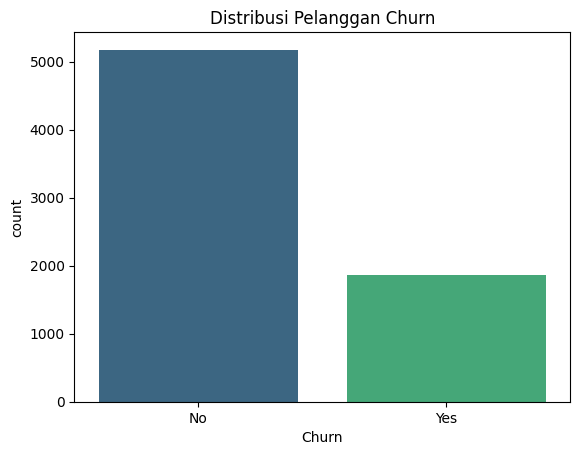

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
# Visualisasi simpel untuk melihat perbandingan target
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribusi Pelanggan Churn')
plt.show()

print(df['Churn'].value_counts(normalize=True) * 100)

Analisis: Data `No` Churn jauh lebih banyak daripada `Yes` Churn, data kita disebut **imbalanced**. Ini merupakan tantangan di Machine Learning agar model tidak hanya jago menebak "No" saja!

### D. **Exploratory Data Analysis (EDA) - Deep Dive**

Secara garis besar, ada tiga cara kita melihat data:

- Univariate Analysis: Fokus pada satu variabel saja. Misal: "Berapa persen pelanggan yang churn di dataset ini?"
- Bivariate Analysis: Melihat hubungan antara dua variabel. Misal: "Apakah orang dengan kontrak bulanan lebih sering churn dibanding kontrak tahunan?"
- Multivariate Analysis: Melihat interaksi antara tiga variabel atau lebih. Misal: "Bagaimana hubungan antara jenis internet, tagihan bulanan, dan churn?"

#### I. Faktor Demografis & Layanan (Bivariate)

Kita akan membedah hubungan antara kategori (Senior Citizen, Kontrak, Internet) dengan keputusan Churn.

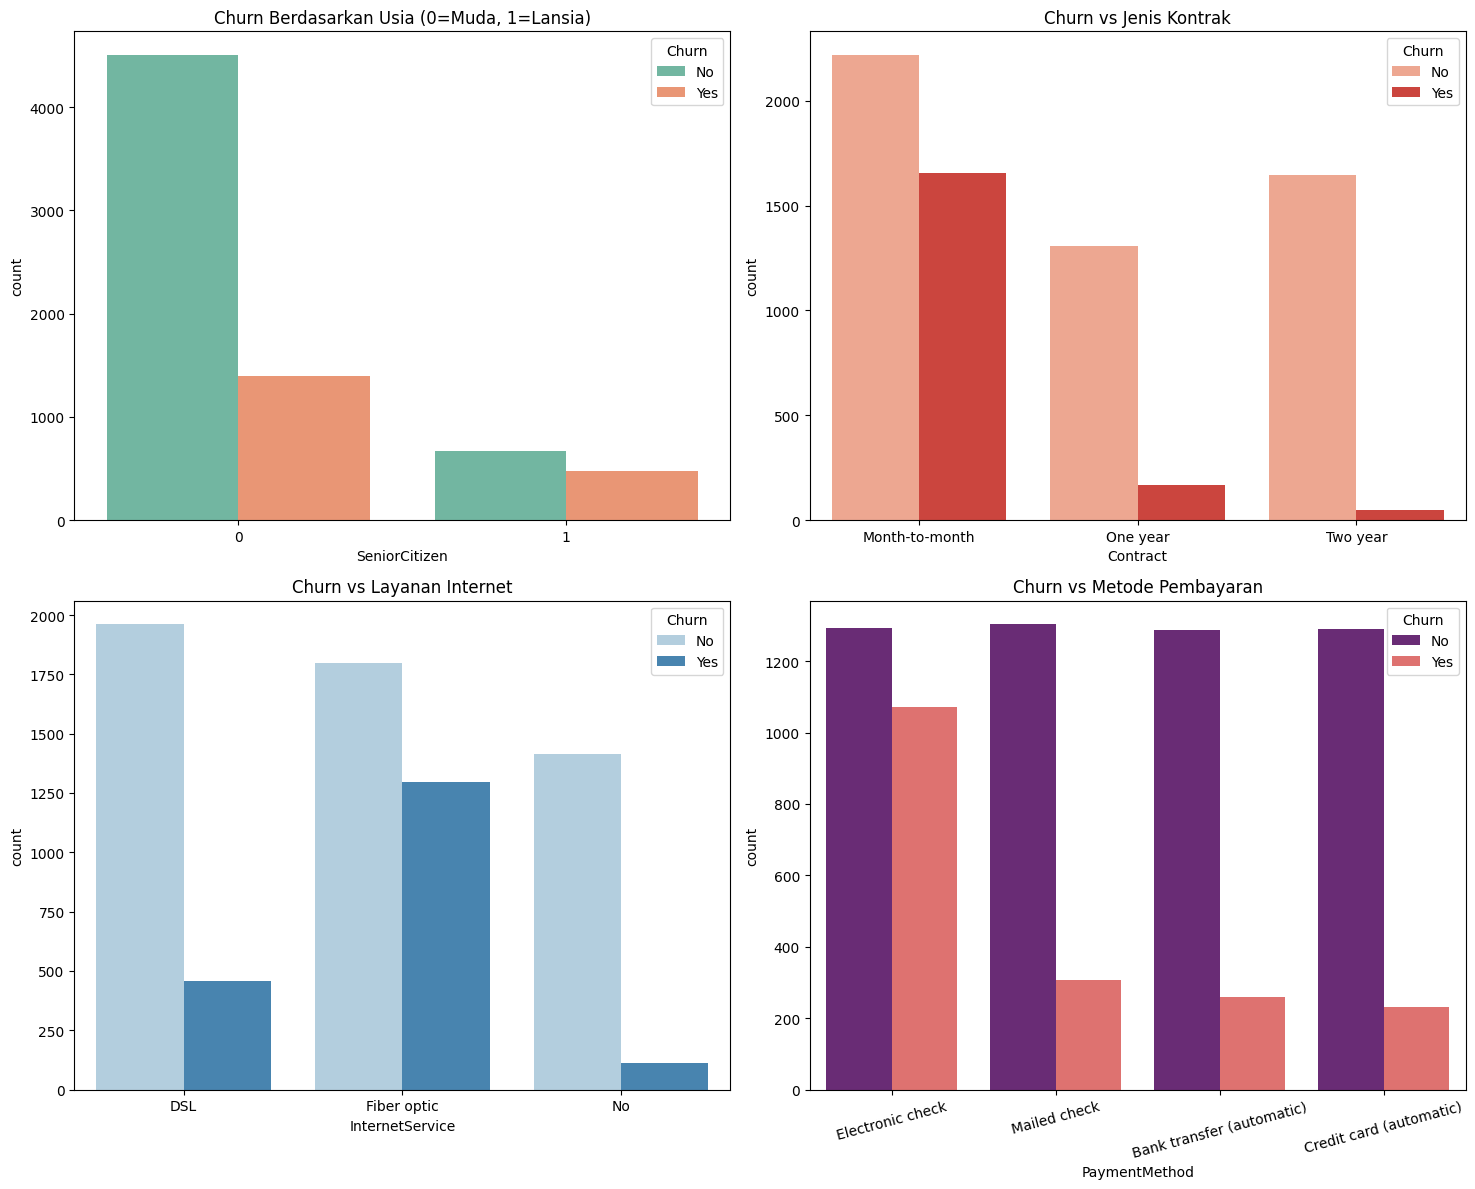

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Senior Citizen
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Churn Berdasarkan Usia (0=Muda, 1=Lansia)')

# 2. Jenis Kontrak (Sangat Penting!)
sns.countplot(x='Contract', hue='Churn', data=df, palette='Reds', ax=axes[0,1])
axes[0,1].set_title('Churn vs Jenis Kontrak')

# 3. Layanan Internet
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Blues', ax=axes[1,0])
axes[1,0].set_title('Churn vs Layanan Internet')

# 4. Metode Pembayaran
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='magma', ax=axes[1,1])
axes[1,1].set_title('Churn vs Metode Pembayaran')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

Insight Utama:
* **The Fiber Optic Paradox**
    * **Temuan:** Pengguna layanan internet *Fiber Optic* memiliki tingkat Churn yang **lebih tinggi** secara signifikan dibandingkan pengguna DSL, meskipun teknologinya lebih cepat.
    * **Hipotesis:** Kemungkinan terdapat masalah ketidakpuasan terhadap harga yang tinggi (Price/Value ratio) atau seringnya terjadi gangguan teknis.

* **The Month-to-Month Trap**
    * **Temuan:** Pelanggan dengan kontrak bulanan (*Month-to-Month*) adalah segmen yang paling tidak stabil. Sebaliknya, pelanggan dengan kontrak 1-2 tahun sangat jarang berpindah.

* **Electronic Check Friction**
    * **Temuan:** Metode pembayaran *Electronic Check* berkorelasi kuat dengan tingkat Churn yang tinggi dibandingkan metode otomatis (Credit Card/Bank Transfer).

* **The "First Year" Critical Period**
    * **Temuan:** Risiko Churn tertinggi terjadi pada masa langganan (Tenure) di bawah 12 bulan. Jika pelanggan bertahan lebih dari 1 tahun, loyalitas mereka meningkat drastis.

#### II. Faktor Angka: Tagihan Bulanan (Numerical Analysis)

Apakah pelanggan yang membayar lebih mahal cenderung lebih mudah pergi?

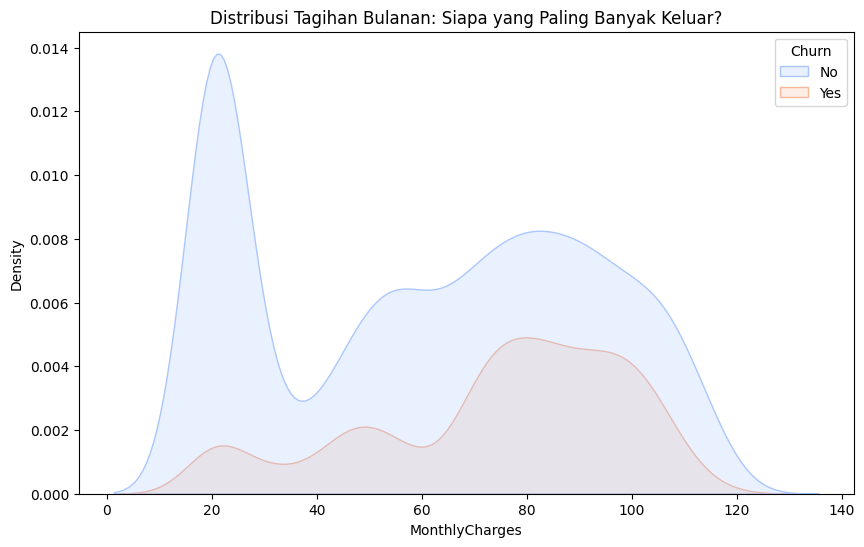

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette='coolwarm')
plt.title('Distribusi Tagihan Bulanan: Siapa yang Paling Banyak Keluar?')
plt.show()

#### III. Correlation Matrix: Mencari Hubungan Tersembunyi
Kita gunakan Heatmap untuk melihat fitur mana yang memiliki korelasi (hubungan) paling kuat.

In [ ]:
# numeric_df = df.select_dtypes(include=['int64', 'float64'])

# plt.figure(figsize=(12, 8))

# # Hitung korelasi
# corr_matrix = numeric_df.corr()

# sns.heatmap(
#     corr_matrix,
#     annot=True,
#     fmt='.2f',
#     cmap='RdYlGn',
#     linewidths=0.5
# )

# plt.title('Correlation Matrix - Hubungan Antar Fitur (Numerik)')
# plt.tight_layout()
# plt.show()

Berdasarkan insight di atas, berikut saran aksi untuk tim bisnis:

> **1. Fokus pada Onboarding (0-6 Bulan Pertama)**
> Berikan insentif atau layanan "White Glove" (bantuan prioritas) untuk pelanggan baru di 6 bulan pertama untuk melewati masa kritis.

> **2. Migrasi Kontrak**
> Buat kampanye marketing yang agresif untuk memindahkan pengguna *Month-to-Month* ke kontrak tahunan dengan penawaran diskon khusus.

> **3. Investigasi Fiber Optic**
> Lakukan audit teknis dan survei kepuasan khusus untuk pelanggan Fiber Optic untuk mengetahui akar masalah (apakah harga atau kualitas jaringan?).

## **5. Data Preparation & Cleaning**

Setelah kita mengenal data kita, sekarang saatnya kita siapkan data tersebut agar siap dilatih oleh model Machine Learning. Ingat prinsip utama AI: ***Garbage In, Garbage Out***. Jika datanya kotor, hasil prediksinya pun akan berantakan.

### **A. Fixing Variables & Inconsistent Data**

Kadang format data kita "rusak" atau tidak konsisten. Kasus paling sering adalah angka yang terbaca sebagai teks (Object).

Masalah: Di dataset ini, kolom `TotalCharges` adalah angka, tapi terbaca sebagai teks karena ada spasi kosong (`" "`). Kita harus mengubahnya menjadi numerik. Spasi tersebut akan otomatis berubah menjadi **NaN (Not a Number)** atau **missing value**.

In [ ]:
# Cek jumlah spasi kosong
print("Jumlah baris dengan spasi kosong di TotalCharges:", len(df[df['TotalCharges'] == " "]))

# Perbaiki: Ubah ke numerik, 'coerce' akan mengubah error (spasi) menjadi NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Tipe data TotalCharges sekarang:", df['TotalCharges'].dtype)

Jumlah baris dengan spasi kosong di TotalCharges: 11
Tipe data TotalCharges sekarang: float64


### **B. Handling Missing Values**

Setelah kita memperbaiki tipe data di atas, muncullah missing values. **Jangan asal isi data!** Mengisi data dengan **nilai yang salah** justru bisa memberikan **"halusinasi"** pada model AI kita. Ada beberapa strategi untuk menanganinya:


1. **Rule-Based Imputation (Paling Akurat)**

   Sebelum menggunakan pendekatan statistik seperti mean atau median, sebaiknya manfaatkan **logika bisnis** atau **domain knowledge**. Pendekatan ini biasanya jauh lebih akurat.

   Contoh Kasus:
   - Logika Tagihan: Jika `TotalCharges` kosong, tapi kita tahu `MonthlyCharges` adalah 100rb dan tenure adalah 5 bulan, maka kita isi TotalCharges dengan $100 \times 5 = 500$rb. Jangan pakai rata-rata semua orang!
   - Logika Layanan: Jika kolom `InternetService` kosong tapi StreamingTV bernilai "Yes", maka secara logika `InternetService` pasti ada (bisa diisi "Fiber" atau "DSL").



2. **Aturan Main (*Rules of Thumb*) dalam Menangani Missing Values**

   Dalam praktik data science, terdapat beberapa pedoman umum yang sering digunakan untuk menentukan strategi penanganan *missing values*. Perlu diingat bahwa aturan ini **bukan hukum mutlak**, melainkan titik awal sebelum melakukan analisis lebih lanjut.

   - Kasus 1: Missing Row Sangat Sedikit (< 5%)

     Jika jumlah baris yang memiliki nilai kosong sangat kecil dibandingkan total data (misalnya dari 7.000 baris hanya 10 yang memiliki nilai kosong), maka baris tersebut dapat langsung dihapus (*drop rows*).

      **Alasan:**
      - Kehilangan data sangat kecil.
      - Tidak berdampak signifikan pada distribusi data.
      - Biasanya tidak memengaruhi performa model secara berarti.

    - Kasus 2: Satu Kolom Missing Terlalu Banyak (> 40–50%)

      Jika sebuah fitur (kolom) memiliki proporsi nilai kosong yang sangat tinggi, bahkan lebih banyak kosong daripada terisi, maka fitur tersebut sering kali sudah tidak informatif.

      **Strategi:**
      - Pertimbangkan untuk menghapus kolom tersebut (*drop column*).
      - Kecuali jika kolom itu sangat penting secara bisnis atau domain.

    - Kasus 3: Imputation (Mengisi Data)

      Jika data tidak dapat dihapus, maka dilakukan *imputation* (pengisian nilai) menggunakan pendekatan statistik sederhana:

      - **Mean (Rata-rata):**  
        Digunakan untuk data numerik dengan distribusi relatif simetris (mendekati normal).

      - **Median:**  
        Digunakan jika data memiliki *outlier* (pencilan) atau distribusinya miring (*skewed*).  
        Median lebih tahan terhadap nilai ekstrem.

      - **Mode (Modus):**  
        Digunakan untuk data kategorikal, misalnya mengisi nilai kosong pada kolom *Gender* dengan kategori yang paling sering muncul.

      ![alt](https://miro.medium.com/v2/resize:fit:1400/0*JD27jGzhDKy1Fbs0.png)

3. **Advanced Imputation Techniques**

    Untuk kasus yang lebih kompleks, pendekatan imputasi lanjutan dapat digunakan agar nilai yang diisi lebih realistis dan mempertahankan pola data.

      - K-Nearest Neighbors (KNN) Imputer

        ![alt txt](https://substackcdn.com/image/fetch/$s_!Djg1!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F52e3919a-ae70-4107-84b9-5ac7c50f7af8_285x235.png)

        Metode ini mengisi nilai kosong dengan melihat beberapa baris data lain yang paling mirip (*nearest neighbors*) berdasarkan fitur-fitur lain yang tersedia.

        **Ide Utama:**
        - Cari data yang paling mirip.
        - Gunakan rata-rata atau nilai dominan dari tetangga tersebut.
        - Cocok untuk data tabular dengan hubungan antar fitur yang kuat.



    - Time Series (Data Berurutan Waktu)

      Untuk data yang memiliki dimensi waktu, terdapat strategi khusus:

      - **Forward Fill (*ffill*):**  
        Mengisi nilai kosong dengan nilai dari waktu sebelumnya.
        ![alt txt](https://towardsdatascience.com/wp-content/uploads/2022/02/0D-FhxVnQ-6Q-PRXB.png)

      - **Backward Fill (*bfill*):**  
        Mengisi nilai kosong dengan nilai dari waktu setelahnya.

        ![alt txt](https://towardsdatascience.com/wp-content/uploads/2022/02/0-iq4kk5REwlebguh.png)

      **Catatan:**
      Metode ini cocok jika perubahan data relatif stabil antar waktu.
    
    - Dan masi banyak lagi....

*Kalau ingin mempelajari strategi imputasi yang lain dan lebih detail, mungkin boleh cek bbrp link dibawah ini:*
- [https://towardsdatascience.com/how-to-fill-missing-data-with-pandas-8cb875362a0d/](https://towardsdatascience.com/how-to-fill-missing-data-with-pandas-8cb875362a0d/)
- [https://www.geeksforgeeks.org/machine-learning/data-imputation-techniques-in-ml/](https://www.geeksforgeeks.org/machine-learning/data-imputation-techniques-in-ml/)


In [ ]:
# Cek jumlah missing values setelah konversi tadi
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
# Solusi: Karena cuma 11 baris dari 7000+ (sangat kecil), kita drop saja
df.dropna(inplace=True)

print("\nMissing values bersih!")


Missing values bersih!


### **C. Handling Outliers**

Outlier adalah data yang nilainya sangat jauh berbeda dibandingkan sebagian besar data lainnya. Nilai ini bisa muncul karena kesalahan input, proses pencatatan yang tidak tepat, atau memang merepresentasikan kejadian yang jarang terjadi namun penting.





**Cara Mendeteksi Outliers**

Beberapa metode umum untuk mengecek keberadaan outlier:



1. **Visualisasi Boxplot**
  ![alt txt](https://encrypted-tbn3.gstatic.com/licensed-image?q=tbn:ANd9GcTDH-9H95LyBmkg1FuP5n04aix0eC6KzKJ4eXUq0iFJyUgNI2lXURbU_FvJ6HRE5cNmvHXBj-rm2ReuSsr-eiT7brQ5w-TdN8qm7toXTT2hG7GaM4M)
  - Menampilkan sebaran data secara ringkas.
  - Outlier biasanya terlihat sebagai titik di luar *whiskers*.
  - Mudah digunakan untuk eksplorasi awal.

2. **Metode Statistik**

- **Z-Score**

  ![alt txt](https://editor.analyticsvidhya.com/uploads/440971.png)

  Digunakan untuk melihat seberapa jauh suatu nilai dari rata-rata dalam satuan standar deviasi.

  $
  Z = \frac{x - \mu}{\sigma}
  $

  Keterangan Variabel pada Z-Score:

  - $x$ : nilai data yang ingin dicek  
  - $\mu$ : rata-rata (mean) dari seluruh data  
  - $\sigma$ : standar deviasi dari data  

  Nilai dengan $(|Z| > 3)$ sering dianggap sebagai kandidat outlier.

- **Interquartile Range (IQR)**

  ![alt txt](https://miro.medium.com/0*pRJpx9hCvvaCCo-t.jpg)

  Metode ini menggunakan kuartil untuk menentukan batas nilai ekstrem.

  $
  IQR = Q3 - Q1
  $

  **Batas bawah:**

  $
  Q1 - 1.5 \times IQR
  $

  **Batas atas:**

  $
  Q3 + 1.5 \times IQR
  $

  Nilai di luar rentang tersebut dianggap sebagai kandidat outlier.


Catatan Penting

> **Jangan langsung menghapus outlier!**

Dalam beberapa kasus seperti **Fraud Detection**, outlier justru merupakan data yang paling berharga karena merepresentasikan kejadian langka yang ingin diprediksi oleh model.

Outlier sebaiknya dihapus **hanya jika**:
- Terbukti merupakan kesalahan input atau pencatatan.
- Tidak realistis secara domain.
- Sangat merusak distribusi data dan performa model (setelah diuji melalui eksperimen).

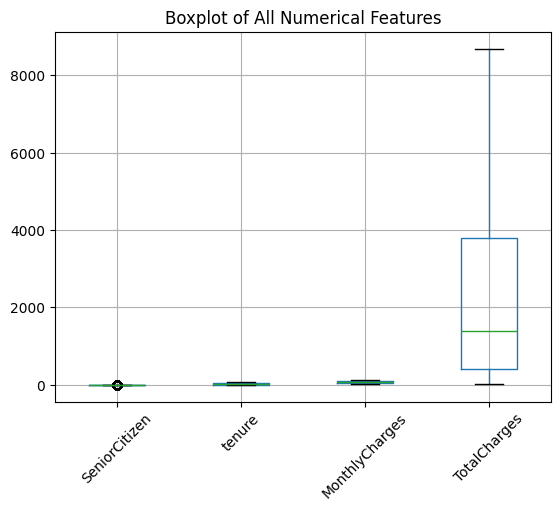

In [ ]:
# Ambil semua kolom numerik
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure()
df[numeric_cols].boxplot(figsize=(14,6))
plt.xticks(rotation=45)
plt.title("Boxplot of All Numerical Features")
plt.show()

In [ ]:
outlier_iqr_flags = pd.DataFrame(index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_iqr_flags[col] = (df[col] < lower) | (df[col] > upper)

# Baris yang memiliki outlier di salah satu kolom
rows_with_outliers_iqr = outlier_iqr_flags.any(axis=1)

print("Total rows with outliers (IQR):", rows_with_outliers_iqr.sum())

Total rows with outliers (IQR): 1142


In [ ]:
from scipy.stats import zscore

z_scores = df[numeric_cols].apply(zscore)

outlier_z_flags = abs(z_scores) > 3

rows_with_outliers_z = outlier_z_flags.any(axis=1)

print("Total rows with outliers (Z-score):", rows_with_outliers_z.sum())

Total rows with outliers (Z-score): 0


Melihat dataset ini, kita tidak perlu melakukan drop outlier karena:

- Aman Secara Statistik: Hasil Z-Score menunjukkan angka 0, yang berarti tidak ada data ekstrem yang akan merusak performa model secara signifikan.

- Logika Bisnis: Nilai tinggi di `TotalCharges` atau angka 1 di `SeniorCitizen` adalah variasi nyata di lapangan, bukan kesalahan input (human error).

- Keakuratan Model: Membuang data ini justru akan membuat AI kita "buta" terhadap profil pelanggan setia atau kelompok lansia.

### **D. Encoding: Mengubah Kategorikal Menjadi Angka**

Sebagian besar model machine learning membutuhkan input berupa angka. Oleh karena itu, fitur kategorikal harus diubah menjadi representasi numerik melalui proses *encoding*.

1. **One-Hot Encoding (OHE)**

    One-Hot Encoding digunakan untuk data kategorikal yang **tidak memiliki urutan** (*nominal*).

    ![alt txt](https://miro.medium.com/1*ggtP4a5YaRx6l09KQaYOnw.png)

    > Batas Aman Penggunaan: Hindari OHE jika jumlah kategori terlalu banyak (*high cardinality*), misalnya lebih dari ±15 kategori.

    > Masalah: Curse of Dimensionality. Jika sebuah fitur memiliki banyak kategori, OHE akan menghasilkan banyak kolom baru.

    **Dampak:**
    - Model menjadi lebih berat.
    - Training lebih lambat.
    - Risiko *overfitting* meningkat.

    Tips: Kelompokkan kategori yang sangat jarang muncul ke dalam kategori **"Other"**.

2. **Ordinal Encoding**

    Ordinal Encoding digunakan untuk kategori yang **memiliki urutan atau tingkatan**.

    ![alt txt](https://media.geeksforgeeks.org/wp-content/uploads/20250918131050615260/apriori_algorithm_7.webp)

    Kapan Digunakan?
    - Ada urutan yang jelas.
    - Makna ranking penting.
    - Jarak antar tingkat relatif konsisten.

    > Perhatian: Jangan gunakan Ordinal Encoding untuk kategori tanpa urutan karena dapat menyesatkan model.

3. **Label Encoding**

    Label Encoding mengubah setiap kategori menjadi angka unik.

    ![alt](https://www.mygreatlearning.com/blog/wp-content/uploads/2020/08/image-37.png)

    > Risiko: Model dapat menganggap ada hubungan urutan padahal tidak ada.

    Cocok Untuk:
    - Tree-based models.
    - Fitur dengan sedikit kategori.

4. **Target Encoding (Mean Encoding)**

    Target Encoding mengganti kategori dengan **rata-rata target** untuk kategori tersebut.

    ![alt](https://miro.medium.com/v2/resize:fit:1400/0*HgIkpL66MJQjDOIY.png)

    Risiko
    - Data leakage jika tidak dilakukan di dalam cross-validation.
    - Overfitting pada dataset kecil.

    Tips Aman
    - Hitung encoding hanya di data train.
    - Gunakan smoothing.
    - Terapkan CV-based encoding.

5. **Frequency / Count Encoding**

    Mengganti kategori dengan jumlah atau proporsi kemunculannya.

    ![alt](https://miro.medium.com/v2/resize:fit:1276/1*l0mPlpqFEK_DSu4OqSnvLg.jpeg)

    Kelebihan:
    - Sederhana.
    - Tidak menambah dimensi.
    - Aman untuk high cardinality.

6. **Binary Encoding / Hash Encoding**

    Digunakan untuk fitur dengan kategori sangat banyak.

    ![alt](https://knowledge.dataiku.com/latest/_images/term-hashing-concept.png)

    Ide Utama
    - Kategori dikonversi menjadi representasi biner atau hash.
    - Jumlah kolom lebih sedikit dibanding OHE.

    Cocok Untuk:
    - High cardinality features.
    - Dataset besar.


Encoding akan kita lakukan di akhir supaya tidak menganggu proses Feature Engineering

### **E. Normalization & Standardization (Scaling)**

Beberapa model machine learning seperti **K-Nearest Neighbors (KNN)** dan **Logistic Regression** sangat sensitif terhadap skala fitur.  
Jika satu kolom memiliki rentang 1–10 sementara kolom lain berada di 1.000–10.000, maka model cenderung menganggap fitur dengan nilai besar lebih penting, meskipun sebenarnya tidak.

Oleh karena itu, dilakukan proses *scaling* untuk menyamakan skala antar fitur.


**A. Normalization (Min-Max Scaling)**

Normalization mengubah nilai fitur ke dalam rentang **0 sampai 1**.

### Rumus

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

### Keterangan Variabel
- $x$ : nilai asli  
- $x_{\min}$ : nilai minimum pada kolom  
- $x_{\max}$ : nilai maksimum pada kolom  
- $x'$ : nilai hasil normalisasi  


### Kapan Digunakan?
- Data memiliki batas bawah dan atas yang jelas.
- Untuk model berbasis jarak seperti KNN atau clustering.
- Neural networks.

**B. Standardization (Z-Score Scaling)**

Standardization mengubah data agar memiliki:
- **Rata-rata = 0**
- **Standar deviasi = 1**

### Rumus

$$
x' = \frac{x - \mu}{\sigma}
$$

### Keterangan Variabel
- $x$ : nilai asli  
- $\mu$ : rata-rata (mean) dari fitur  
- $\sigma$ : standar deviasi dari fitur  
- $x'$ : nilai hasil standardisasi  

> Catatan untuk Tree-Based Models

> Model berbasis pohon seperti **Random Forest**, **Decision Tree**, atau **XGBoost** pada dasarnya **tidak wajib** dilakukan scaling karena mereka membagi data berdasarkan threshold, bukan jarak antar nilai.

> Namun, melakukan scaling juga **tidak akan merusak performa** model tersebut.



*Note: Pada sesi ini, kita **belum melakukan scaling terlebih dahulu** karena masih berada pada tahap **Data Preparation**. Soalnya kita belum melakukan feature engineering dan EDA lebih lanjut. Scaling akan dilakukan tepat sebelum proses pemodelan.*

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Ambil semua kolom numerik
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# NORMALIZATION (Min-Max)

# Membuat scaler
minmax_scaler = MinMaxScaler()

# Fit hanya pada data training (nanti saat modeling!)
# Di demo ini kita hanya contoh cara pakainya
df_minmax = df.copy()
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df[numeric_cols])

# ------------------

# STANDARDIZATION (Z-Score)

# Membuat scaler
standard_scaler = StandardScaler()

df_standard = df.copy()
df_standard[numeric_cols] = standard_scaler.fit_transform(df[numeric_cols])


In [ ]:
# LIHAT PERBANDINGAN

print("Sebelum Scaling:")
display(df[numeric_cols].head())

print("\nSetelah Min-Max Scaling:")
display(df_minmax[numeric_cols].head())

print("\nSetelah Standardization:")
display(df_standard[numeric_cols].head())

Sebelum Scaling:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65



Setelah Min-Max Scaling:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0.0,0.000000,0.115423,0.001275
1,0.0,0.464789,0.385075,0.215867
2,0.0,0.014085,0.354229,0.010310
3,0.0,0.619718,0.239303,0.210241
4,0.0,0.014085,0.521891,0.015330



Setelah Standardization:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,-0.440327,-1.280248,-1.161694,-0.994194
1,-0.440327,0.064303,-0.260878,-0.173740
2,-0.440327,-1.239504,-0.363923,-0.959649
3,-0.440327,0.512486,-0.747850,-0.195248
4,-0.440327,-1.239504,0.196178,-0.940457


### **F. Drop Feature**
Terakhir, kita hapus kolom yang tidak berguna untuk prediksi, seperti `customerID`. ID pelanggan hanyalah identitas unik yang tidak memiliki pola terhadap perilaku Churn.

In [ ]:
# Hapus kolom ID jika masih ada
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

print("Jumlah fitur sekarang:", len(df.columns))

Jumlah fitur sekarang: 20


## **6. Feature Engineering**

Feature Engineering adalah proses membuat, mengubah, atau memilih fitur agar model machine learning dapat menangkap pola penting dalam data dengan lebih baik.

Sering kali, kualitas fitur jauh lebih berpengaruh terhadap performa model dibandingkan pilihan algoritma itu sendiri.

*“Better features beat better models.”*

# 1. Feature Creation (Membuat Fitur Baru)

Membuat fitur baru dari fitur yang sudah ada.

## A. Fitur Matematis

Menggabungkan atau mentransformasi fitur numerik.

### Contoh:
- Total pengeluaran = harga × jumlah
- Rasio = pengeluaran / pendapatan
- Selisih waktu = tanggal bayar − tanggal daftar

## B. Fitur Waktu (Datetime Features)

Ekstraksi informasi dari kolom tanggal/waktu.

### Bisa dibuat:
- Tahun, bulan, hari
- Hari dalam minggu
- Akhir pekan (weekend)
- Jam transaksi
- Selisih antar event

## C. Aggregation Features

Mengelompokkan data lalu membuat ringkasan statistik.

### Contoh:
- Rata-rata transaksi per user
- Jumlah transaksi 30 hari terakhir
- Maksimum pembelian per pelanggan
- Total login per minggu


# 2. Transformasi Fitur

Mengubah distribusi atau skala fitur.

## A. Log / Power Transform

Digunakan untuk:
- Mengurangi skewness.
- Menekan pengaruh outlier.

### Contoh:
- $\log(x + 1)$
- Box-Cox
- Yeo-Johnson

## B. Binning / Discretization

Mengubah numerik menjadi kategori.

### Contoh:
- Umur → kelompok usia
- Penghasilan → low / medium / high

# 3. Encoding

Ini udah dibahas di atas :D

# 4. Interaksi Antar Fitur

Menggabungkan dua atau lebih fitur.

### Contoh:
- Umur × Pengeluaran
- Lama berlangganan × Jumlah komplain
- Diskon × Jumlah item

Sering membantu model linear.

# 5. Domain Knowledge Features

Fitur yang dibuat berdasarkan pemahaman bisnis sering kali paling kuat.

### Contoh:
- Customer churn → lama sejak terakhir transaksi
- Fraud → kecepatan transaksi beruntun
- E-commerce → conversion rate user

In [ ]:
# 1. Membuat Group Tenure (Masa Langganan)
# Alasan: Pola orang langganan 1 bulan vs 5 bulan mungkin sama (sama-sama baru).
# Kita kelompokkan biar model lebih mudah menangkap pola "New" vs "Loyal".
def tenure_group(months):
    if months <= 12:
        return '1_Year_Less'
    elif months <= 24:
        return '2_Years'
    elif months <= 36:
        return '3_Years'
    elif months <= 48:
        return '4_Years'
    elif months <= 60:
        return '5_Years'
    else:
        return '6_Years_Plus'

df['tenure_group'] = df['tenure'].apply(tenure_group)

# 2. Total Services (Jumlah Layanan yang Dipakai)
# Alasan: Logikanya, semakin banyak layanan yang dipakai (Internet + TV + Telepon),
# semakin malas orang itu untuk pindah (ribet).
services_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Kita hitung berapa "Yes" di kolom-kolom layanan
# Note: Kita perlu memastikan kolom ini belum di-encode jadi angka dulu
df['num_services'] = (df[services_cols] == 'Yes').sum(axis=1)

# 3. Ratio Tagihan (Harga Naik atau Tidak?)
# Alasan: Kita punya 'TotalCharges' dan 'tenure'.
# Kalau Total / Tenure jauh beda sama MonthlyCharges sekarang, berarti harga dia mungkin baru naik/turun.
# Tambahkan proteksi divisi dengan 0 (epsilon)
df['avg_charges'] = df['TotalCharges'] / (df['tenure'] + 0.01)


# 4. Fitur Keluarga (Punya Pasangan + Tanggungan)
# Alasan: Orang yang berkeluarga biasanya lebih stabil ekonominya dibanding single.
df['has_family'] = ((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes')).astype(int)

# --- CEK HASILNYA ---
print("Contoh Data dengan Fitur Baru:")
display(df[['tenure', 'tenure_group', 'num_services', 'MonthlyCharges', 'avg_charges', 'has_family']].head())

NameError: name 'df' is not defined

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# 1. Label Encoding untuk kolom biner
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# 2. One Hot Encoding untuk kolom multiclass
multiclass_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport',
                   'StreamingTV', 'StreamingMovies', 'Contract',
                   'PaymentMethod', 'tenure_group']

encoder = OneHotEncoder(drop='first', sparse_output=False).set_output(transform="pandas")

# Fit & Transform hanya pada kolom multiclass
df_ohe = encoder.fit_transform(df[multiclass_cols])

# Gabungkan kembali dengan dataframe utama dan hapus kolom aslinya
df = pd.concat([df.drop(columns=multiclass_cols), df_ohe], axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_2_Years,tenure_group_3_Years,tenure_group_4_Years,tenure_group_5_Years,tenure_group_6_Years_Plus
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  num_services                           7032 non-null   int64  
 11  avg_charg

In [ ]:
df.to_csv('telco_cleaned.csv', index=False)

## **7. Machine Learning Modeling**

Setelah kita memiliki data yang bersih dan fitur yang bermakna, saatnya memilih model untuk melakukan prediksi.


### **A. Supervised Learning - Regresi & Klasifikasi**

#### I. Linear Regression

Digunakan untuk memprediksi nilai numerik kontinu (misal: harga rumah, pendapatan).

![alt txt](https://cdn.analyticsvidhya.com/wp-content/uploads/2024/09/375512-1.webp)

#### Rumus:

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n
$$

#### Penjelasan Variabel:

- $\hat{y}$ : nilai prediksi
- $x_i$ : fitur ke-$i$
- $\beta_i$ : bobot/koefisien
- $\beta_0$ : intercept

#### Kapan Dipakai?

- Sebagai baseline regresi
- Hubungan data relatif linear
- Butuh interpretabilitas tinggi


#### II. Logistic Regression (Klasifikasi)

Meskipun namanya "regresi", model ini digunakan untuk klasifikasi biner.

Ia memprediksi probabilitas menggunakan fungsi sigmoid.

![alttxt](https://miro.medium.com/v2/resize:fit:1400/1*2IAHsCEZaZtZ9ybziYPDEQ.jpeg)

#### Rumus:

$$
P(y=1 | x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

dengan:

$$
z = \beta_0 + \beta_1x_1 + \dots + \beta_nx_n
$$

#### Penjelasan:

- $P(y=1|x)$ : probabilitas kelas positif
- $e$ : bilangan Euler ($\approx 2.718$)
- $z$ : kombinasi linear
- $\beta_0$ : bias

#### Kapan Dipakai?

- Baseline klasifikasi
- Interpretabel
- Cepat dilatih


#### III. Decision Tree

Model yang belajar dengan membelah data secara rekursif menggunakan aturan *Ya/Tidak*.

![](https://jcsites.juniata.edu/faculty/rhodes/ml/images/decTreeEx1.jpg)

![](https://storage.googleapis.com/lds-media/images/gini-impurity-diagram.width-1200.png)

#### Gini Impurity:

$$
Gini = 1 - \sum_{i=1}^{c} p_i^2
$$

- $p_i$ : proporsi kelas $i$
- $c$ : jumlah kelas

#### Kapan Dipakai?

- Hubungan non-linear
- Mudah divisualisasikan


#### IV. Random Forest

Ensemble berbasis **Bagging**.

![](https://media.geeksforgeeks.org/wp-content/uploads/20251216121929631349/random_forest_algorithm.webp)

## Kenapa Random Forest Dibuat?

Decision Tree sangat intuitif dan mudah dipahami, tetapi memiliki kelemahan besar:

### Kelemahan Decision Tree
- **Mudah Overfitting**  
  Pohon bisa tumbuh sangat dalam dan menghafal data training.
- **Terlalu Rule-Based**  
  Aturan yang sangat spesifik sering tidak bekerja baik pada data baru.
- **Sensitif terhadap Noise**  
  Sedikit perubahan pada data bisa menghasilkan struktur pohon yang sangat berbeda.

## Solusi: Random Forest

Random Forest mengatasi masalah ini dengan membangun **banyak Decision Tree** secara acak dan menggabungkan hasilnya.

### Prinsip Utama:
1. **Bootstrap Sampling**  
   Setiap pohon dilatih dari sampel acak data.
2. **Random Feature Selection**  
   Setiap split hanya melihat subset fitur.
3. **Voting / Averaging**  
   Prediksi akhir diambil dari mayoritas pohon

#### Prinsip:

$$
\hat{y} = \text{mode}(\text{Tree}_1, \dots, \text{Tree}_n)
$$

#### Kapan Dipakai?

- Mengurangi overfitting
- Stabil
- Robust terhadap outlier

#### V. Support Vector Machine (SVM)

Mencari hyperplane dengan margin maksimal.
![](https://pelatihan-ui.com/beta/wp-content/uploads/2024/01/SVM-1024x620.png)

#### Rumus:

$$
f(x) = \text{sign}(\mathbf{w}^T \mathbf{x} + b)
$$

- $\mathbf{w}$ : bobot
- $b$ : bias

#### Kapan Dipakai?

- Dimensi tinggi
- Kelas terpisah jelas

#### VI. Gradient Boosting — The Big Three

Boosting membangun pohon **secara sekuensial**, belajar dari residual.

![](https://towardsdatascience.com/wp-content/uploads/2022/05/1PJXOO3x2HC_XfnxvjN-dEg.png)
![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRfSsJ_qrEsM2ZXDHuUnobCoanhqNxg_hQT_Q&s)

### **B. Unsupervised Learning**

#### I. k-Nearest Neighbors (k-NN)

Menentukan kelas berdasarkan jarak tetangga.

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT3gz-qfBeD5VIqZ4lvM9ex1kWfMr6WiFqPYA&s)

#### Euclidean Distance:

$$
d(p,q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}
$$

#### II. Principal Component Analysis (PCA)

Reduksi dimensi sambil mempertahankan varians.

![](https://devopedia.org/images/article/139/4543.1548137789.jpg)

#### Kapan Dipakai?

- Visualisasi
- Mempercepat training


# Evaluation Metrics — Cara Menilai Performa Model

Tidak ada model yang "bagus" tanpa metrik evaluasi yang tepat.

Pemilihan metrik **sangat tergantung pada tujuan bisnis dan karakteristik data** (balanced vs imbalanced, cost error, dsb).

##  Confusion Matrix (Dasar Semua Metrik)

Untuk klasifikasi biner:

|               | Predicted Positive | Predicted Negative |
|-------------|------------------|------------------|
| Actual Positive | TP | FN |
| Actual Negative | FP | TN |

Keterangan:
- **TP (True Positive)**: Prediksi positif & benar
- **TN (True Negative)**: Prediksi negatif & benar
- **FP (False Positive)**: Salah memprediksi positif
- **FN (False Negative)**: Salah memprediksi negatif


# Metrics untuk Klasifikasi


## 1️⃣ Accuracy

Persentase prediksi yang benar.

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

### Kapan Dipakai?
- Dataset seimbang
- Cost FP dan FN relatif sama

⚠️ **Bahaya:** Tidak cocok untuk data imbalance.

---

## 2️⃣ Precision

Seberapa banyak prediksi positif yang benar.

$$
Precision = \frac{TP}{TP + FP}
$$

### Cocok Untuk:
- Spam detection
- Fraud alert (false alarm mahal)

---

## 3️⃣ Recall (Sensitivity)

Seberapa banyak kasus positif yang berhasil ditangkap.

$$
Recall = \frac{TP}{TP + FN}
$$

### Cocok Untuk:
- Deteksi penyakit
- Fraud detection
- Churn prediction

---

## 4️⃣ F1-Score

Rata-rata harmonik precision & recall.

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

### Cocok Untuk:
- Data imbalance
- Butuh keseimbangan FP & FN

---

## 5️⃣ ROC Curve & AUC

ROC menggambar:

- TPR = Recall
- FPR = FP rate

$$
TPR = \frac{TP}{TP + FN}
$$

$$
FPR = \frac{FP}{FP + TN}
$$

**AUC** = luas area di bawah kurva.

### Interpretasi:
- 0.5 = random
- 1.0 = sempurna

---

## 6️⃣ Log Loss (Cross-Entropy)

Menilai kualitas probabilitas prediksi.

$$
LogLoss = -\frac{1}{N} \sum_{i=1}^{N}
\left[y_i \log(p_i) + (1-y_i)\log(1-p_i)\right]
$$

### Cocok Untuk:
- Model probabilistik
- Kompetisi

---

# 📉 Metrics untuk Regresi

---

## 1️⃣ Mean Absolute Error (MAE)

$$
MAE = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
$$

Stabil terhadap outlier.

---

## 2️⃣ Mean Squared Error (MSE)

$$
MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

Memberi penalti besar untuk error besar.

---

## 3️⃣ Root Mean Squared Error (RMSE)

$$
RMSE = \sqrt{MSE}
$$

Satuan sama dengan target.

---

## 4️⃣ R-Squared ($R^2$)

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}
{\sum (y_i - \bar{y})^2}
$$

Mengukur proporsi variasi yang dijelaskan model.

---

# 📊 Metrics untuk Clustering

---

## 1️⃣ Silhouette Score

$$
s = \frac{b - a}{\max(a, b)}
$$

- $a$ = jarak intra-cluster
- $b$ = jarak terdekat ke cluster lain

---

## 2️⃣ Davies–Bouldin Index

Lebih kecil lebih baik.

---

# 🎯 Cara Memilih Metrik

| Kasus | Fokus |
|------|------|
| Fraud / Penyakit | Recall |
| Spam Filter | Precision |
| Balanced Class | Accuracy |
| Regresi Harga | RMSE |
| Clustering | Silhouette |

---

> 📌 **Rule of Thumb:**  
> Jangan hanya lihat accuracy — pahami cost kesalahan.


## **8. Strategi Validasi — Cross Validation**


### Kenapa Tidak Cukup Train-Test Split?

Satu kali split bisa bias.

### Jenis:

#### K-Fold CV
Estimasi stabil.

![](https://towardsdatascience.com/wp-content/uploads/2023/12/1N45hocCMP0u4nXLe0WuSvw.png)

#### Stratified CV
Wajib untuk data imbalance.

![](https://www.researchgate.net/publication/367073570/figure/fig3/AS:11431281241062706@1714916312942/Schematic-diagram-of-Stratified-K-fold-cross-validation.tif)

#### Time Series Split
Tidak boleh shuffle.

![](https://www.kdnuggets.com/wp-content/uploads/Cross_Validation_Ferrer_6-scaled.png)

### Split Ratio Default:

- 80:20 / 70:30
- Dataset besar: 98:1:1


### **A. Persiapan Data**

Mari kita load dataset yang sudah dibersihkan dan siapkan untuk modeling.

In [ ]:
print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df['Churn'].value_counts())

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

Dataset shape: (7032, 39)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Features shape: (7032, 38)
Target shape: (7032,)


### **B. Model Comparison — 6 Model Face-Off dengan F1 Score**

Kita akan membandingkan 6 model berbeda menggunakan **80:20 train-test split**. Metric utama yang digunakan adalah **F1 Score** karena data kita imbalanced.

**F1 Score** adalah harmonic mean antara Precision dan Recall:

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

F1 Score cocok untuk kasus imbalanced karena mempertimbangkan false positive dan false negative.

In [ ]:
# Install libraries yang diperlukan
!pip install catboost lightgbm xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.5 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import time
import warnings
warnings.filterwarnings('ignore')

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

Train set size: (5625, 38)
Test set size: (1407, 38)

Train target distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64


In [ ]:
# Scaling features (untuk model yang memerlukan scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")
print(f"Feature means after scaling: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Feature stds after scaling: {X_train_scaled.std(axis=0)[:5]}")

Scaling completed!
Feature means after scaling: [-8.58967218e-17 -4.73695157e-17 -8.08439735e-17 -3.15796771e-17
 -1.29160880e-16]
Feature stds after scaling: [1. 1. 1. 1. 1.]


In [ ]:
# Definisikan semua model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'CatBoost': CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1,
                                   random_state=42, verbose=0),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                               random_state=42, verbose=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                            random_state=42, eval_metric='logloss')
}

# Dictionary untuk menyimpan hasil
results = {
    'Model': [],
    'F1 Score': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'Training Time (s)': []
}

print("=" * 80)
print("TRAINING AND EVALUATING 6 MODELS")
print("=" * 80)

# Train dan evaluate setiap model
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Gunakan scaled data untuk Logistic Regression, unscaled untuk yang lain
    if name == 'Logistic Regression':
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    else:
        X_train_use = X_train
        X_test_use = X_test

    # Training
    start_time = time.time()
    model.fit(X_train_use, y_train)
    training_time = time.time() - start_time

    # Prediction
    y_pred = model.predict(X_test_use)

    # Calculate metrics
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    # Store results
    results['Model'].append(name)
    results['F1 Score'].append(f1)
    results['Accuracy'].append(acc)
    results['Precision'].append(prec)
    results['Recall'].append(rec)
    results['Training Time (s)'].append(training_time)

    print(f"{name} completed in {training_time:.2f}s")
    print(f"F1 Score: {f1:.4f} | Accuracy: {acc:.4f}")

print("\n" + "=" * 80)
print("TRAINING COMPLETED!")
print("=" * 80)

TRAINING AND EVALUATING 6 MODELS

Training Logistic Regression...
Logistic Regression completed in 0.05s
F1 Score: 0.5839 | Accuracy: 0.7974

Training Decision Tree...
Decision Tree completed in 0.05s
F1 Score: 0.4918 | Accuracy: 0.7591

Training Random Forest...
Random Forest completed in 0.62s
F1 Score: 0.5414 | Accuracy: 0.7832

Training CatBoost...
CatBoost completed in 0.88s
F1 Score: 0.5932 | Accuracy: 0.8031

Training LightGBM...
LightGBM completed in 0.21s
F1 Score: 0.5590 | Accuracy: 0.7903

Training XGBoost...
XGBoost completed in 0.50s
F1 Score: 0.5670 | Accuracy: 0.7839

TRAINING COMPLETED!


In [ ]:
# Create comparison DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("\nMODEL COMPARISON RESULTS (Sorted by F1 Score)")
print("=" * 100)
display(results_df.style.background_gradient(cmap='RdYlGn', subset=['F1 Score', 'Accuracy']))

# Highlight best model
best_model = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1 Score']
print(f"\nBEST MODEL: {best_model} with F1 Score = {best_f1:.4f}")


MODEL COMPARISON RESULTS (Sorted by F1 Score)


,Model,F1 Score,Accuracy,Precision,Recall,Training Time (s)
0,CatBoost,0.593245,0.803127,0.657980,0.540107,0.883166
1,Logistic Regression,0.583942,0.797441,0.643087,0.534759,0.052008
2,XGBoost,0.566952,0.783937,0.606707,0.532086,0.499112
3,LightGBM,0.559043,0.790334,0.633898,0.500000,0.212629
4,Random Forest,0.541353,0.783227,0.618557,0.481283,0.616148
5,Decision Tree,0.491754,0.759062,0.559727,0.438503,0.052480



BEST MODEL: CatBoost with F1 Score = 0.5932


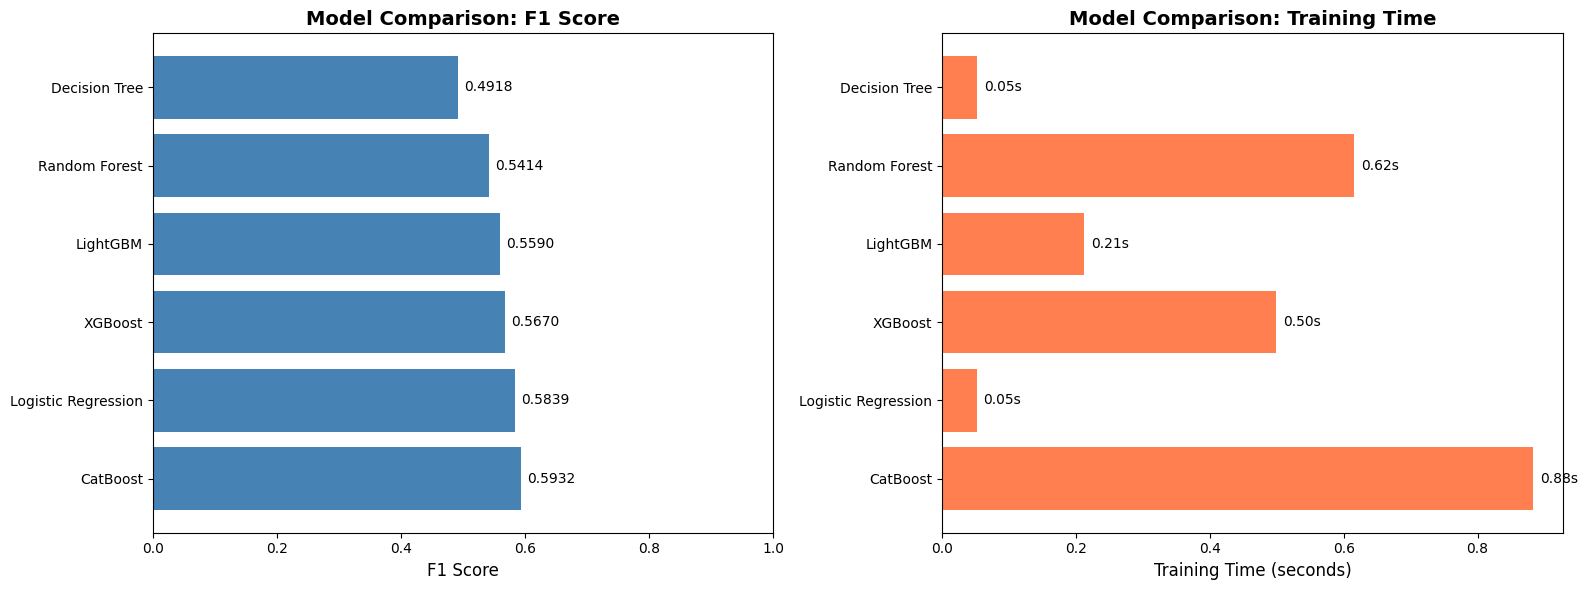

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 Score comparison
axes[0].barh(results_df['Model'], results_df['F1 Score'], color='steelblue')
axes[0].set_xlabel('F1 Score', fontsize=12)
axes[0].set_title('Model Comparison: F1 Score', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1)
for i, v in enumerate(results_df['F1 Score']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

# Training time comparison
axes[1].barh(results_df['Model'], results_df['Training Time (s)'], color='coral')
axes[1].set_xlabel('Training Time (seconds)', fontsize=12)
axes[1].set_title('Model Comparison: Training Time', fontsize=14, fontweight='bold')
for i, v in enumerate(results_df['Training Time (s)']):
    axes[1].text(v + 0.01, i, f'{v:.2f}s', va='center')

plt.tight_layout()
plt.show()


DETAILED ANALYSIS FOR CATBOOST

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.66      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



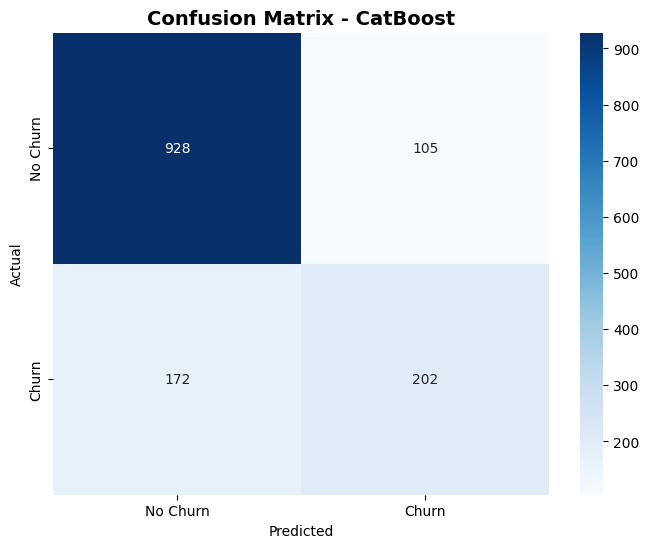

In [ ]:
# Detailed analysis for best model
best_model_name = results_df.iloc[0]['Model']
best_model_obj = models[best_model_name]

# Use appropriate data
if best_model_name == 'Logistic Regression':
    X_test_use = X_test_scaled
else:
    X_test_use = X_test

y_pred_best = best_model_obj.predict(X_test_use)

print(f"\nDETAILED ANALYSIS FOR {best_model_name.upper()}")
print("=" * 80)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### **C. Stratified K-Fold Cross Validation Demo**

**Stratified K-Fold CV** memastikan setiap fold memiliki proporsi kelas yang sama dengan dataset asli. Ini sangat penting untuk data imbalanced seperti kasus Churn kita.

![](https://www.researchgate.net/publication/367073570/figure/fig3/AS:11431281241062706@1714916312942/Schematic-diagram-of-Stratified-K-fold-cross-validation.tif)

**Keuntungan Stratified CV:**
- Setiap fold representatif terhadap distribusi kelas
- Mengurangi variance dalam estimasi performa
- Lebih reliable untuk data imbalanced

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Kita akan demo dengan Random Forest
model_cv = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Setup Stratified K-Fold (5 folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-Fold Stratified Cross Validation...")
print("=" * 80)

# Perform CV dengan berbagai metrics
scoring_metrics = ['f1', 'accuracy', 'precision', 'recall']
cv_results = {}

for metric in scoring_metrics:
    scores = cross_val_score(model_cv, X, y, cv=skf, scoring=metric)
    cv_results[metric] = scores

    print(f"\n{metric.upper()}:")
    print(f"  Individual fold scores: {[f'{s:.4f}' for s in scores]}")
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

print("\n" + "=" * 80)
print("Cross Validation Completed!")
print("=" * 80)

Running 5-Fold Stratified Cross Validation...

F1:
  Individual fold scores: ['0.5784', '0.5854', '0.5556', '0.5819', '0.5988']
  Mean: 0.5800 (+/- 0.0281)

ACCURACY:
  Individual fold scores: ['0.8031', '0.8067', '0.7895', '0.8058', '0.8122']
  Mean: 0.8035 (+/- 0.0152)

PRECISION:
  Individual fold scores: ['0.6714', '0.6809', '0.6314', '0.6810', '0.6937']
  Mean: 0.6717 (+/- 0.0427)

RECALL:
  Individual fold scores: ['0.5080', '0.5134', '0.4960', '0.5080', '0.5267']
  Mean: 0.5104 (+/- 0.0199)

Cross Validation Completed!


## 4. Hyperparameter Tuning — Mengatur "Setelan" Model

Setiap model Machine Learning memiliki **hyperparameter**, yaitu parameter yang **ditentukan sebelum training** dan mengontrol bagaimana model belajar.

Berbeda dengan **parameter model** (seperti bobot $\beta$ pada Linear / Logistic Regression) yang dipelajari otomatis dari data, **hyperparameter kita atur secara manual**.

### Contoh Hyperparameter

| Model | Contoh Hyperparameter | Fungsi |
|------|------------------|--------|
| Decision Tree | `max_depth` | Membatasi kedalaman pohon |
| Random Forest | `n_estimators` | Jumlah pohon |
| XGBoost | `learning_rate` | Kecepatan belajar |
| KNN | `n_neighbors` | Jumlah tetangga |
| Logistic Regression | `C` | Kekuatan regularisasi |
| SVM | `kernel`, `C`, `gamma` | Bentuk hyperplane |

### Kenapa Perlu Tuning?

Jika hyperparameter tidak tepat:

- Terlalu kompleks → overfitting
- Terlalu sederhana → underfitting
- Training lama & boros resource
- Performa tidak optimal

**Tujuan tuning:**  
mencari kombinasi hyperparameter yang memberikan **performansi terbaik di data validasi**.

## Metode Hyperparameter Search

### 1. Grid Search (Brute Force)

Mencoba **semua kombinasi** hyperparameter yang kita tentukan.

**Contoh:**  
`max_depth = [3, 5, 7]`  
`n_estimators = [100, 300]`  

→ total 6 kombinasi dicoba.

**Pro:**  
- Menyeluruh
- Pasti mencoba semua

**Con:**  
- Sangat lambat jika parameternya banyak

### 2. Random Search

Mencoba kombinasi **secara acak** dari ruang parameter.

**Pro:**  
- Jauh lebih cepat
- Sering menemukan hasil bagus tanpa mencoba semuanya

### 3. Optuna (Bayesian Optimization)

Beda dengan Grid Search yang mencoba semua kombinasi secara buta, Optuna belajar dari percobaan sebelumnya. Jika suatu area parameter memberikan hasil buruk, ia akan menghindarinya dan fokus mencari di area yang menjanjikan.

**Pro:**  
- Sangat efisien
- Standar industri / kompetisi saat ini


Trick:

Konsep Penanganan Imbalance dengan Weights
Karena data kita tidak seimbang (lebih banyak No daripada Yes), kita memberikan beban kesalahan yang lebih tinggi kepada model jika ia salah menebak pelanggan yang Yes Churn.

Logikanya: "Salah menebak 1 orang yang mau pindah (Churn) lebih fatal daripada salah menebak 1 orang yang tetap bertahan."

In [ ]:
# Install optuna jika belum ada
!pip install optuna -q

import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
import numpy as np

# 1. Menghitung Class Weights secara manual berdasarkan distribusi data training
# Tujuannya agar model memberikan perhatian ekstra pada kelas minoritas (Churn)
counts = y_train.value_counts()
weight_for_0 = 1.0
weight_for_1 = counts[0] / counts[1] # Rasio No/Yes
class_weights = [weight_for_0, weight_for_1]

print(f"Calculated Class Weights: No={weight_for_0:.2f}, Yes={weight_for_1:.2f}")

# 2. Definisi Objective Function untuk Optuna
def objective(trial):
    # Search Space: Menentukan range parameter yang ingin dicoba
    params = {
        "iterations": trial.suggest_int("iterations", 100, 2000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 1e-8, 10, log=True),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),
        "class_weights": class_weights, # Menggunakan weight yang sudah dihitung
        "verbose": False,
        "random_state": 42,
        "allow_writing_files": False
    }

    # Stratified K-Fold Cross Validation
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []

    # Loop Cross Validation
    for train_idx, val_idx in skf.split(X_train, y_train):
        # Bagi data menjadi Fold Training dan Fold Validation
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Training Model
        model = CatBoostClassifier(**params)
        model.fit(X_fold_train, y_fold_train)

        # Prediksi dan Hitung Skor
        preds = model.predict(X_fold_val)
        score = f1_score(y_fold_val, preds)
        f1_scores.append(score)

    # Kembalikan rata-rata F1 Score (Optuna akan mencoba memaksimalkan nilai ini)
    return np.mean(f1_scores)

# 3. Menjalankan Optimasi
print("\nStarting Optimization with Optuna...")
study = optuna.create_study(direction="maximize") # Kita ingin F1 setinggi mungkin
study.optimize(objective, n_trials=30) # Mencoba 30 kombinasi berbeda

print("\n" + "="*50)
print("OPTIMIZATION COMPLETED!")
print(f"Best F1 Score dari CV: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 28.6 MB/s eta 0:00:00


[I 2026-01-27 12:28:32,600] A new study created in memory with name: no-name-0da7dfe1-a95e-4e63-94a6-8802d70e4556


Calculated Class Weights: No=1.00, Yes=2.76

Starting Optimization with Optuna...


[I 2026-01-27 12:28:38,119] Trial 0 finished with value: 0.6309966045420093 and parameters: {'iterations': 174, 'depth': 7, 'learning_rate': 0.09048604640010893, 'l2_leaf_reg': 5.682891011742937, 'random_strength': 1.05099969821063, 'bootstrap_type': 'MVS'}. Best is trial 0 with value: 0.6309966045420093.
[I 2026-01-27 12:28:47,764] Trial 1 finished with value: 0.5841452968723896 and parameters: {'iterations': 468, 'depth': 6, 'learning_rate': 0.28807528507728947, 'l2_leaf_reg': 8.476228271012685, 'random_strength': 5.471388001425549, 'bootstrap_type': 'Bayesian'}. Best is trial 0 with value: 0.6309966045420093.
[I 2026-01-27 12:28:56,799] Trial 2 finished with value: 0.599626565421948 and parameters: {'iterations': 327, 'depth': 7, 'learning_rate': 0.10694571443189889, 'l2_leaf_reg': 1.0638586056415789, 'random_strength': 0.4899563744305652, 'bootstrap_type': 'Bernoulli'}. Best is trial 0 with value: 0.6309966045420093.
[I 2026-01-27 12:29:08,563] Trial 3 finished with value: 0.598540


OPTIMIZATION COMPLETED!
Best F1 Score dari CV: 0.6410
Best Hyperparameters:
  iterations: 192
  depth: 5
  learning_rate: 0.0494548416734976
  l2_leaf_reg: 6.450625415816363
  random_strength: 3.163672805602822e-05
  bootstrap_type: MVS


In [ ]:
# Ambil parameter terbaik hasil tuning (kecuali class_weights yang manual)
best_params = study.best_params
best_params["class_weights"] = class_weights # Masukkan kembali weight-nya

# Latih model akhir
final_model = CatBoostClassifier(**best_params, verbose=0)
final_model.fit(X_train, y_train)

# Prediksi di data testing (Blind Test)
final_preds = final_model.predict(X_test)

print("\nFINAL MODEL PERFORMANCE (After Optuna + Weighting)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=['No Churn', 'Churn']))

# Bandingkan dengan Baseline
baseline_f1 = results_df[results_df['Model'] == 'CatBoost']['F1 Score'].values[0]
tuned_f1 = f1_score(y_test, final_preds)

print(f"F1 Score Baseline: {baseline_f1:.4f}")
print(f"F1 Score After Tuning: {tuned_f1:.4f}")
print(f"Improvement: {((tuned_f1 - baseline_f1) / baseline_f1 * 100):.2f}%")


FINAL MODEL PERFORMANCE (After Optuna + Weighting)
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407

F1 Score Baseline: 0.5932
F1 Score After Tuning: 0.6139
Improvement: 3.49%


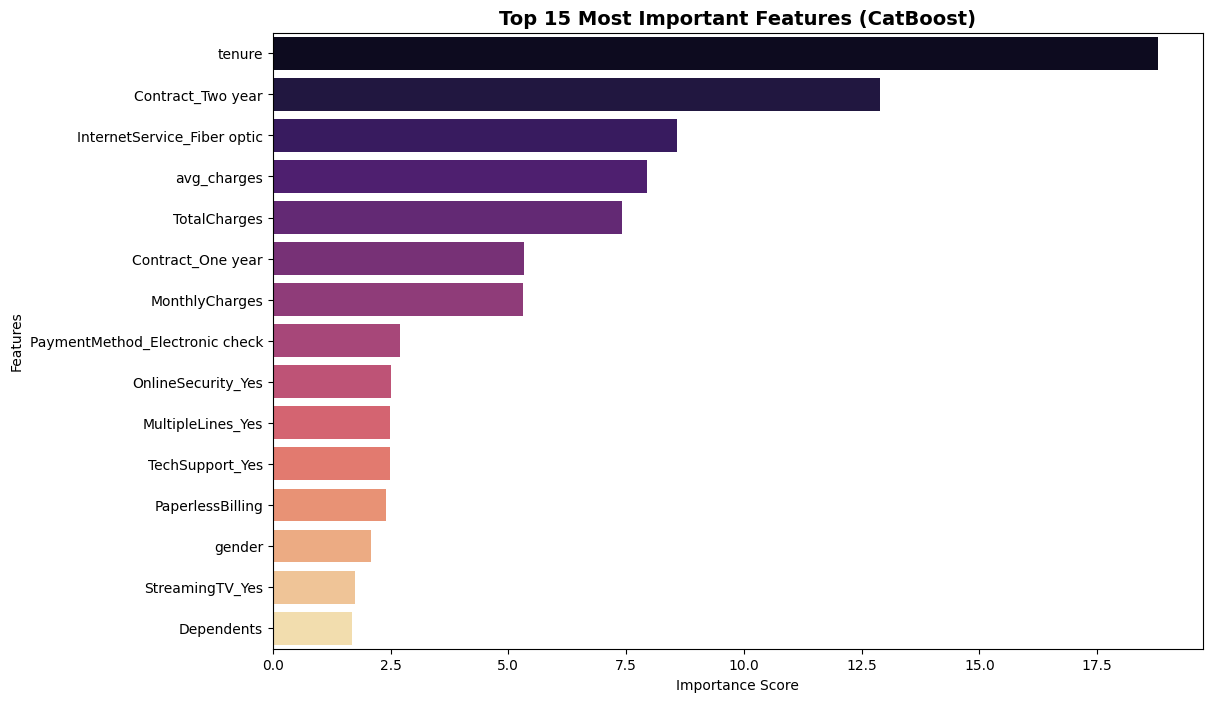

In [ ]:
# Mengambil feature importance dari model CatBoost terbaik
feature_importance = final_model.get_feature_importance()
feature_names = X_train.columns

# Membuat DataFrame untuk visualisasi
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette='magma')
plt.title('Top 15 Most Important Features (CatBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

SHAP Summary Plot:


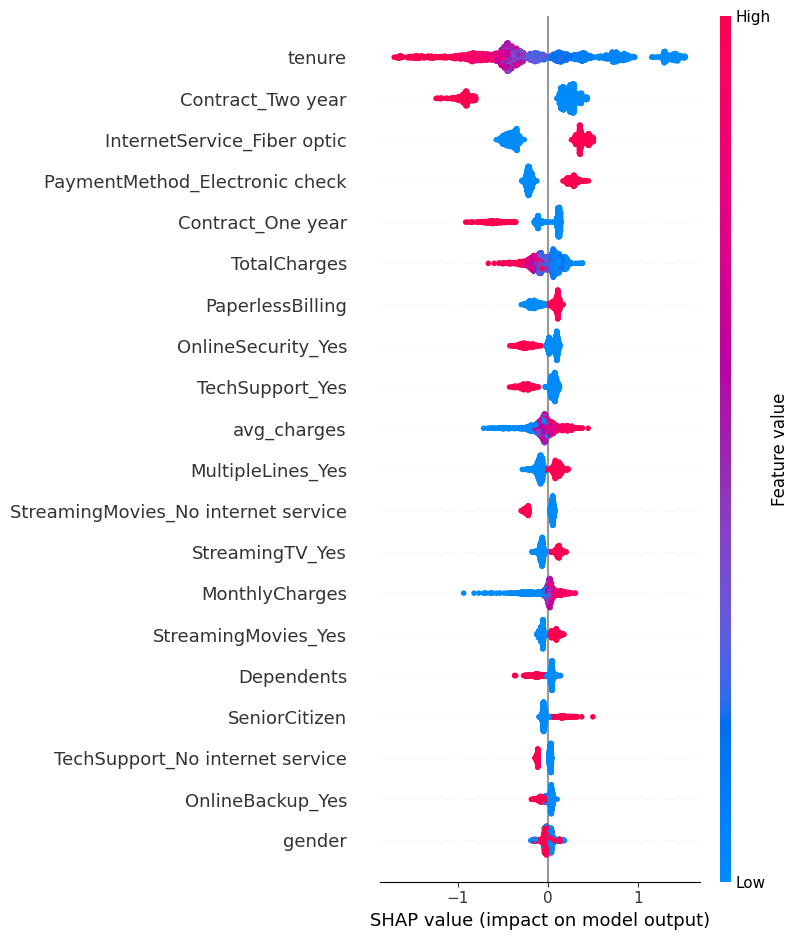


Explaining prediction for customer at index 0:


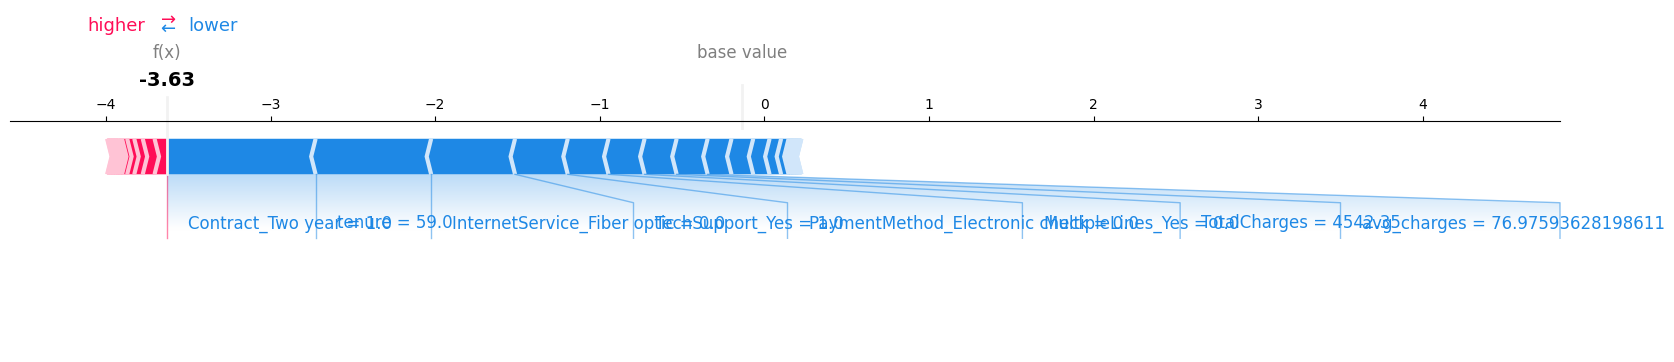

In [ ]:
# Install SHAP library
!pip install shap -q
import shap

# Inisialisasi explainer dengan model CatBoost kita
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# A. Summary Plot: Melihat dampak fitur secara keseluruhan
print("SHAP Summary Plot:")
shap.summary_plot(shap_values, X_test)

# B. Individual Explanation (Local): Mengapa Pelanggan X diprediksi Churn?
# Kita ambil contoh satu pelanggan dari test set
sample_idx = 0
print(f"\nExplaining prediction for customer at index {sample_idx}:")

# Force plot untuk melihat faktor pendorong vs penahan
shap.initjs() # Penting agar visualisasi muncul di notebook
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx, :],
    X_test.iloc[sample_idx, :],
    matplotlib=True
)